# EEG Motor İmgelem — Klasik Makine Öğrenmesi (v5)
## PhysioNet EEG Motor Movement/Imagery Dataset

**Veri seti:** https://www.physionet.org/content/eegmmidb/1.0.0/  
**Görev:** Sol el (T1) vs Sağ el (T2) motor imgelem sınıflandırması  
**Yöntem:** FBCSP + SVM / Random Forest / KNN + PCA boyut azaltma

### v4 → v5 İyileştirmeleri
| Parametre | v4 | v5 |
|---|---|---|
| Frekans bantları | 2 (mu, beta) | 4 (theta, mu, beta1, beta2) — FBCSP |
| Koşu/denek | 3 imgelem | 6 (gerçek + imgelem) → ~180 epoch |
| SVM ayarı | sabit C=10 | GridSearchCV (C, gamma) |
| Denek sayısı | 40 | 40 (artırılabilir) |

## 1. Kütüphane Kurulumu ve İthalat

In [1]:
# !pip install mne scikit-learn numpy pandas matplotlib seaborn scipy

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from mne.decoding import CSP

mne.set_log_level('WARNING')
print(f"MNE     : {mne.__version__}")
print(f"sklearn : {sklearn.__version__}")

MNE     : 1.12.1
sklearn : 1.8.0


## 2. Parametreler

### FBCSP (Filter Bank CSP)
Tek bant yerine 4 farklı frekans bandı üzerinde ayrı ayrı CSP uygulanır.
- **Theta (4-8 Hz):** Motor hazırlık örüntüleri
- **Mu (8-12 Hz):** ERD — motor imgelemin en güçlü göstergesi
- **Beta1 (13-20 Hz):** Hareket sırasında desenkronizasyon
- **Beta2 (20-30 Hz):** Hareket sonrası ERS (senkronizasyon)

### Genişletilmiş Koşu Seti
- R03/R07/R11: Gerçek sol/sağ yumruk (T1=sol, T2=sağ)
- R04/R08/R12: Sol/sağ imgelem (T1=sol, T2=sağ)  
Aynı etiket yapısı → doğrudan birleştirilebilir → ~180 epoch/denek

In [3]:
# ── Veri yolu ─────────────────────────────────────────────────────────
DATA_DIR = '../physioNet_Dataset'   # EDF dosyalarının bulunduğu dizin

# ── Denek ve koşu ayarları ─────────────────────────────────────────────
N_SUBJECTS   = 40    # 40-109 arası kullanılabilir
IMAGERY_RUNS = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']  # 6 koşu

# ── FBCSP: 4 frekans bandı ─────────────────────────────────────────────
BANDS = {
    'theta' : (4.0,  8.0),
    'mu'    : (8.0, 12.0),
    'beta1' : (13.0, 20.0),
    'beta2' : (20.0, 30.0),
}

# ── Epoch ve kanal ayarları ────────────────────────────────────────────
TMIN, TMAX       = 1.0, 4.0   # Saf imgelem penceresi (uyarı gecikmesi atlanır)
USE_ALL_CHANNELS = True        # 64 kanal — CSP için maksimum uzamsal bilgi
MOTOR_CHANNELS   = ['C3','CZ','C4','FC3','FC4','CP3','CP4',
                     'FC1','FC2','C1','C2','CP1','CP2']

# ── Model parametreleri ────────────────────────────────────────────────
N_CSP_COMPONENTS = 6   # Her bant için 6 bileşen → toplam 24 özellik
N_FOLDS          = 5   # Within-subject stratified CV

print(f"Denek sayısı     : {N_SUBJECTS}")
print(f"Koşu/denek       : {len(IMAGERY_RUNS)} → ~{len(IMAGERY_RUNS)*30} epoch/denek")
print(f"Frekans bantları : {list(BANDS.keys())} ({len(BANDS)} bant)")
print(f"Toplam CSP özell.: {N_CSP_COMPONENTS * len(BANDS)}")
print(f"Epoch penceresi  : {TMIN}-{TMAX}s  |  CV: {N_FOLDS}-fold")

Denek sayısı     : 40
Koşu/denek       : 6 → ~180 epoch/denek
Frekans bantları : ['theta', 'mu', 'beta1', 'beta2'] (4 bant)
Toplam CSP özell.: 24
Epoch penceresi  : 1.0-4.0s  |  CV: 5-fold


## 3. Veri Yükleme ve Ön İşleme

Her denek için ön işleme adımları:
1. EDF dosyalarını yükle ve birleştir
2. Kanal isimlerini normalize et, montage ayarla
3. Her frekans bandı için ayrı kopyala ve bant-geçiren filtre uygula
4. Çentik filtresi (60 Hz — ABD şebeke gürültüsü)
5. T1/T2 annotation'larına göre etiketli epoch oluştur

In [4]:
def load_subject_bands(subject_id, runs, data_dir, bands,
                       use_all_ch, motor_chs, tmin, tmax):
    """
    Bir denek için tüm koşuları birleştirir, her bant için ayrı
    filtrelenmiş epoch döndürür.
    Dönüş: {band_name: mne.Epochs} veya None
    """
    sub  = f'S{subject_id:03d}'
    raws = []
    for run in runs:
        path = f'{data_dir}/{sub}/{sub}{run}.edf'
        try:
            raws.append(mne.io.read_raw_edf(path, preload=True, verbose=False))
        except FileNotFoundError:
            pass

    if not raws:
        return None

    raw = mne.concatenate_raws(raws)
    raw.rename_channels({ch: ch.rstrip('.').upper() for ch in raw.ch_names})
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'),
                    on_missing='ignore')
    raw.pick('eeg')

    if not use_all_ch:
        avail = [c for c in motor_chs if c in raw.ch_names]
        if len(avail) >= 3:
            raw.pick(avail)

    # Annotation'lardan olayları çıkar (filtrelemeden önce)
    events, ann_id = mne.events_from_annotations(raw, verbose=False)
    ev_id = {k: v for k, v in ann_id.items() if k in ['T1', 'T2']}
    if not ev_id:
        return None

    # Her bant için: filtrele → epoch
    band_epochs = {}
    for bname, (lf, hf) in bands.items():
        rb = raw.copy()
        rb.filter(lf, hf, fir_design='firwin', verbose=False)
        rb.notch_filter(60, verbose=False)
        ep = mne.Epochs(rb, events, ev_id, tmin=tmin, tmax=tmax,
                        proj=True, picks='eeg', baseline=None,
                        preload=True, verbose=False)
        ep.drop_bad(verbose=False)
        band_epochs[bname] = ep

    return band_epochs

print("Yükleme fonksiyonu hazır.")

Yükleme fonksiyonu hazır.


In [5]:
subjects_data = {}

print(f"Toplam {N_SUBJECTS} denek yükleniyor...\n")
for sid in range(1, N_SUBJECTS + 1):
    result = load_subject_bands(sid, IMAGERY_RUNS, DATA_DIR, BANDS,
                                USE_ALL_CHANNELS, MOTOR_CHANNELS, TMIN, TMAX)
    if result is None:
        continue
    min_ep = min(len(v) for v in result.values())
    if min_ep < 20:
        print(f"  S{sid:03d}: {min_ep} epoch — yetersiz, atlandı")
        continue
    subjects_data[sid] = result
    ch_n = len(list(result.values())[0].ch_names)
    print(f"  S{sid:03d}: {min_ep} epoch | {ch_n} kanal")

sfreq = list(list(subjects_data.values())[0].values())[0].info['sfreq']
print(f"\nYüklenen denek sayısı : {len(subjects_data)}")
print(f"Örnekleme frekansı    : {sfreq} Hz")
print(f"Bant sayısı           : {len(BANDS)}")

Toplam 40 denek yükleniyor...

  S001: 90 epoch | 64 kanal
  S002: 90 epoch | 64 kanal
  S003: 90 epoch | 64 kanal
  S004: 90 epoch | 64 kanal
  S005: 90 epoch | 64 kanal
  S006: 90 epoch | 64 kanal
  S007: 90 epoch | 64 kanal
  S008: 90 epoch | 64 kanal
  S009: 90 epoch | 64 kanal
  S010: 90 epoch | 64 kanal
  S011: 90 epoch | 64 kanal
  S012: 90 epoch | 64 kanal
  S013: 90 epoch | 64 kanal
  S014: 90 epoch | 64 kanal
  S015: 90 epoch | 64 kanal
  S016: 90 epoch | 64 kanal
  S017: 90 epoch | 64 kanal
  S018: 90 epoch | 64 kanal
  S019: 90 epoch | 64 kanal
  S020: 90 epoch | 64 kanal
  S021: 90 epoch | 64 kanal
  S022: 90 epoch | 64 kanal
  S023: 90 epoch | 64 kanal
  S024: 90 epoch | 64 kanal
  S025: 90 epoch | 64 kanal
  S026: 90 epoch | 64 kanal
  S027: 90 epoch | 64 kanal
  S028: 90 epoch | 64 kanal
  S029: 90 epoch | 64 kanal
  S030: 90 epoch | 64 kanal
  S031: 90 epoch | 64 kanal
  S032: 90 epoch | 64 kanal
  S033: 90 epoch | 64 kanal
  S034: 85 epoch | 64 kanal
  S035: 90 epoch 

## 4. FBCSP Özellik Çıkarma

**CSP (Common Spatial Patterns):** İki sınıf arasında varyans farkını maksimize eden
uzamsal filtreler öğrenir. Motor imgelem için literatürdeki standart yöntemdir.

**FBCSP:** CSP'yi tek bir bant yerine birden fazla bant üzerinde uygular.
Her bant bağımsız CSP öğrenir; bantların özellikleri birleştirilerek
`n_bands × n_csp_components` boyutlu bir vektör elde edilir.

**Veri sızıntısı önlemi:** CSP her fold'un eğitim verisinde fit edilir,
test verisine sadece transform uygulanır.

In [6]:
def get_raw_bands(band_epochs, n_csp):
    """Her bant için ham EEG verisi ve etiketleri döndürür.
    CSP fold içinde eğitilecek — burada sadece numpy array döner."""

    le = LabelEncoder()
    first_ep = list(band_epochs.values())[0]
    y = le.fit_transform(first_ep.events[:, -1])
    X_bands = {bname: ep.get_data() for bname, ep in band_epochs.items()}
    return X_bands, y


def within_subject_cv(X_bands, y, classifiers, n_folds, n_csp,
                      use_grid_search=True):
    """
    Within-subject stratified K-fold CV — FBCSP pipeline.

    Her fold:
      1. Her bant için CSP.fit_transform(train) ve .transform(test)
      2. Bantları hstack ile birleştir
      3. SVM için GridSearchCV (iç 3-fold) ile C ve gamma optimize et
      4. Diğer sınıflandırıcıları direkt eğit
    """
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {name: {'acc': [], 'f1': []} for name in classifiers}

    # SVM arama ızgarası
    svm_param_grid = {
        'clf__C'    : [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.01]
    }

    for train_idx, test_idx in skf.split(list(X_bands.values())[0], y):
        y_train, y_test = y[train_idx], y[test_idx]

        # FBCSP: her bant için CSP fit+transform
        fold_train, fold_test = [], []
        for bname, X_raw in X_bands.items():
            csp = CSP(n_components=n_csp, reg='ledoit_wolf',
                      log=True, norm_trace=False)
            try:
                fold_train.append(csp.fit_transform(X_raw[train_idx], y_train))
                fold_test.append(csp.transform(X_raw[test_idx]))
            except Exception:
                fold_train.append(np.zeros((len(train_idx), n_csp)))
                fold_test.append(np.zeros((len(test_idx),  n_csp)))

        X_tr = np.hstack(fold_train)   # (n_train, n_bands × n_csp)
        X_te = np.hstack(fold_test)    # (n_test,  n_bands × n_csp)

        for name, pipe in classifiers.items():
            pipe_clone = sklearn.clone(pipe)

            # SVM için GridSearchCV uygula
            if use_grid_search and 'SVM' in name:
                gs = GridSearchCV(pipe_clone, svm_param_grid,
                                  cv=3, scoring='accuracy', n_jobs=-1)
                gs.fit(X_tr, y_train)
                y_pred = gs.best_estimator_.predict(X_te)
            else:
                pipe_clone.fit(X_tr, y_train)
                y_pred = pipe_clone.predict(X_te)

            results[name]['acc'].append(accuracy_score(y_test, y_pred))
            results[name]['f1'].append(f1_score(y_test, y_pred,
                                                average='macro'))
    return results

print("FBCSP + CV fonksiyonları hazır.")
print(f"  Toplam CSP özelliği: {len(BANDS)} bant × {N_CSP_COMPONENTS} bileşen = "
      f"{len(BANDS)*N_CSP_COMPONENTS}")

FBCSP + CV fonksiyonları hazır.
  Toplam CSP özelliği: 4 bant × 6 bileşen = 24


## 5. Sınıflandırıcılar ve Within-Subject CV

**SVM (RBF):** Yüksek boyutlu uzayda doğrusal olmayan ayrım yapar.
EEG BCI literatüründe en başarılı klasik sınıflandırıcı.

**Random Forest:** Overfitting'e dayanıklı, özellik önemini raporlar.

**KNN (k=7):** Mesafeye dayalı basit sınıflandırıcı, karşılaştırma için.

In [7]:
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=300,
                                          max_features='sqrt',
                                          min_samples_split=4,
                                          random_state=42, n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

all_subject_results = {}

print(f"Within-subject {N_FOLDS}-fold CV ({len(subjects_data)} denek, FBCSP)\n")
print(f"{'Denek':<8} {'SVM':>10} {'Rand.Forest':>12} {'KNN':>10}")
print("-" * 44)

for sid, band_dict in subjects_data.items():
    X_bands, y = get_raw_bands(band_dict, N_CSP_COMPONENTS)
    if len(np.unique(y)) < 2:
        continue
    res = within_subject_cv(X_bands, y, classifiers,
                            N_FOLDS, N_CSP_COMPONENTS, use_grid_search=True)
    all_subject_results[sid] = res

    svm_acc = np.mean(res['SVM (RBF)']['acc'])
    rf_acc  = np.mean(res['Random Forest']['acc'])
    knn_acc = np.mean(res['KNN (k=7)']['acc'])
    print(f"S{sid:03d}     {svm_acc:>10.3f} {rf_acc:>12.3f} {knn_acc:>10.3f}")

print(f"\nTamamlandı. {len(all_subject_results)} denek değerlendirildi.")

Within-subject 5-fold CV (40 denek, FBCSP)

Denek           SVM  Rand.Forest        KNN
--------------------------------------------
S001          0.722        0.711      0.733
S002          0.756        0.744      0.744
S003          0.689        0.667      0.711
S004          0.644        0.633      0.644
S005          0.544        0.511      0.567
S006          0.533        0.489      0.578
S007          0.956        0.944      0.978
S008          0.656        0.656      0.656
S009          0.489        0.533      0.500
S010          0.767        0.778      0.722
S011          0.600        0.578      0.600
S012          0.556        0.533      0.511
S013          0.700        0.667      0.644
S014          0.633        0.556      0.622
S015          0.689        0.689      0.722
S016          0.633        0.622      0.700
S017          0.467        0.478      0.489
S018          0.600        0.533      0.567
S019          0.667        0.600      0.644
S020          0.500        0.53

## 6. Sonuçlar — Boyut Azaltma Olmadan (FBCSP)

In [8]:
# Denek bazlı ortalamaları topla
results_no_pca = {}
clf_names = list(classifiers.keys())

for clf_name in clf_names:
    subject_accs = [np.mean(all_subject_results[sid][clf_name]['acc'])
                    for sid in all_subject_results]
    subject_f1s  = [np.mean(all_subject_results[sid][clf_name]['f1'])
                    for sid in all_subject_results]
    results_no_pca[clf_name] = {
        'accuracy_mean': np.mean(subject_accs),
        'accuracy_std' : np.std(subject_accs),
        'f1_mean'      : np.mean(subject_f1s),
        'f1_std'       : np.std(subject_f1s),
        'subject_accs' : subject_accs
    }

n_features = N_CSP_COMPONENTS * len(BANDS)

print("=" * 62)
print(f"BOYUT AZALTMA YOK — FBCSP ({len(BANDS)} bant × {N_CSP_COMPONENTS} = {n_features} özellik)")
print("=" * 62)
for name, r in results_no_pca.items():
    print(f"\n{name}:")
    print(f"  Doğruluk : {r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}")
    print(f"  F1 Skoru : {r['f1_mean']:.4f} ± {r['f1_std']:.4f}")
    accs = np.array(r['subject_accs'])
    print(f"  Medyan   : {np.median(accs):.4f} | Min: {accs.min():.3f} | Max: {accs.max():.3f}")

BOYUT AZALTMA YOK — FBCSP (4 bant × 6 = 24 özellik)

SVM (RBF):
  Doğruluk : 0.6522 ± 0.1188
  F1 Skoru : 0.6412 ± 0.1241
  Medyan   : 0.6500 | Min: 0.433 | Max: 0.978

Random Forest:
  Doğruluk : 0.6278 ± 0.1211
  F1 Skoru : 0.6165 ± 0.1266
  Medyan   : 0.6222 | Min: 0.378 | Max: 0.989

KNN (k=7):
  Doğruluk : 0.6499 ± 0.1193
  F1 Skoru : 0.6394 ± 0.1239
  Medyan   : 0.6444 | Min: 0.444 | Max: 0.978


## 7. Boyut Azaltma — PCA

**Ödev kriteri:** Özellik çıkarma (CSP) sonrasında, model eğitimi öncesinde
PCA uygulanmalı ve PCA öncesi/sonrası karşılaştırılmalıdır.

**Pipeline:** Ham EEG → FBCSP (24 özellik) → PCA (%95 varyans) → Sınıflandırıcı

PCA her fold içinde eğitim verisinde `fit`, test verisinde `transform` yapılır.
Bu şekilde veri sızıntısı tamamen engellenir.

In [9]:
def within_subject_cv_pca(X_bands, y, classifiers_pca, n_folds, n_csp):
    """Within-subject CV — FBCSP + PCA + sınıflandırıcı, sızıntısız."""
    skf     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {name: {'acc': [], 'f1': []} for name in classifiers_pca}

    svm_param_grid = {
        'clf__C'    : [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.01]
    }

    for train_idx, test_idx in skf.split(list(X_bands.values())[0], y):
        y_train, y_test = y[train_idx], y[test_idx]

        # FBCSP
        fold_train, fold_test = [], []
        for bname, X_raw in X_bands.items():
            csp = CSP(n_components=n_csp, reg='ledoit_wolf',
                      log=True, norm_trace=False)
            try:
                fold_train.append(csp.fit_transform(X_raw[train_idx], y_train))
                fold_test.append(csp.transform(X_raw[test_idx]))
            except Exception:
                fold_train.append(np.zeros((len(train_idx), n_csp)))
                fold_test.append(np.zeros((len(test_idx),  n_csp)))

        X_tr = np.hstack(fold_train)
        X_te = np.hstack(fold_test)

        for name, pipe in classifiers_pca.items():
            pipe_clone = sklearn.clone(pipe)
            if 'SVM' in name:
                gs = GridSearchCV(pipe_clone, svm_param_grid,
                                  cv=3, scoring='accuracy', n_jobs=-1)
                gs.fit(X_tr, y_train)
                y_pred = gs.best_estimator_.predict(X_te)
            else:
                pipe_clone.fit(X_tr, y_train)
                y_pred = pipe_clone.predict(X_te)

            results[name]['acc'].append(accuracy_score(y_test, y_pred))
            results[name]['f1'].append(f1_score(y_test, y_pred, average='macro'))
    return results


# PCA dahil pipeline'lar (%95 varyans)
classifiers_pca = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                          random_state=42, n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    KNeighborsClassifier(n_neighbors=7))
    ])
}

all_subject_results_pca = {}
print(f"PCA'lı within-subject CV ({len(subjects_data)} denek)...\n")

for sid, band_dict in subjects_data.items():
    X_bands, y = get_raw_bands(band_dict, N_CSP_COMPONENTS)
    if len(np.unique(y)) < 2:
        continue
    res = within_subject_cv_pca(X_bands, y, classifiers_pca,
                                N_FOLDS, N_CSP_COMPONENTS)
    all_subject_results_pca[sid] = res

results_pca = {}
for clf_name in clf_names:
    subject_accs = [np.mean(all_subject_results_pca[sid][clf_name]['acc'])
                    for sid in all_subject_results_pca]
    subject_f1s  = [np.mean(all_subject_results_pca[sid][clf_name]['f1'])
                    for sid in all_subject_results_pca]
    results_pca[clf_name] = {
        'accuracy_mean': np.mean(subject_accs),
        'accuracy_std' : np.std(subject_accs),
        'f1_mean'      : np.mean(subject_f1s),
        'f1_std'       : np.std(subject_f1s),
        'subject_accs' : subject_accs
    }

print("=" * 62)
print("PCA SONRASI — FBCSP + PCA(%95 varyans)")
print("=" * 62)
for name, r in results_pca.items():
    print(f"\n{name}:")
    print(f"  Doğruluk : {r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}")
    print(f"  F1 Skoru : {r['f1_mean']:.4f} ± {r['f1_std']:.4f}")

PCA'lı within-subject CV (40 denek)...

PCA SONRASI — FBCSP + PCA(%95 varyans)

SVM (RBF):
  Doğruluk : 0.6456 ± 0.1209
  F1 Skoru : 0.6352 ± 0.1254

Random Forest:
  Doğruluk : 0.6194 ± 0.1124
  F1 Skoru : 0.6057 ± 0.1186

KNN (k=7):
  Doğruluk : 0.6465 ± 0.1202
  F1 Skoru : 0.6363 ± 0.1246


## 8. PCA Görselleştirme ve Analizi

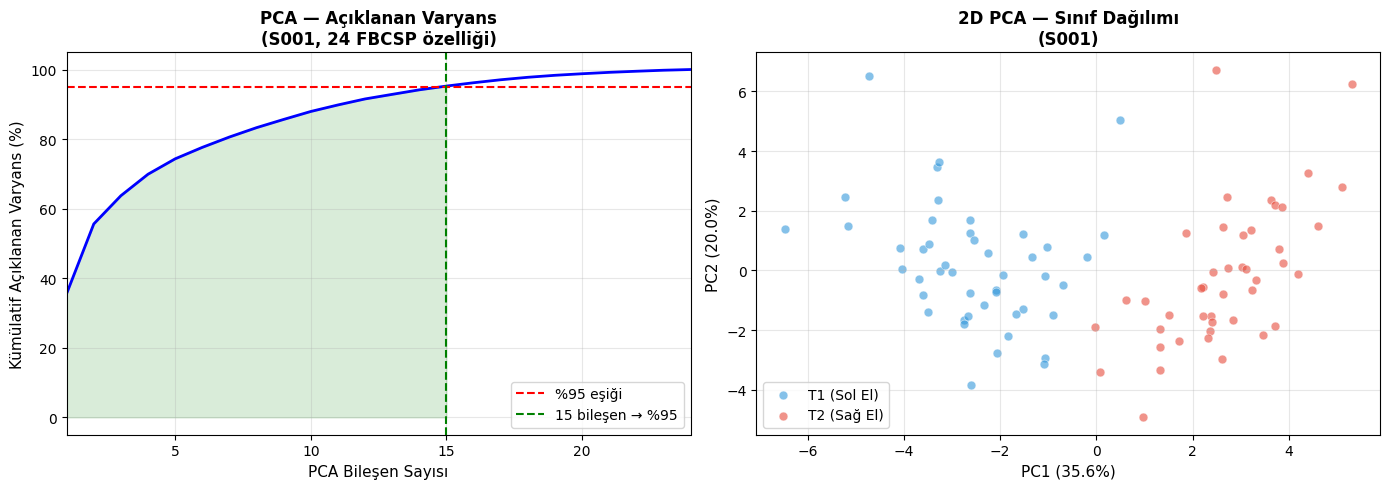


Boyut azaltma özeti:
  Giriş: 24 FBCSP özelliği
  Çıkış: 15 PCA bileşeni (%95 varyans korundu)
  Azaltma: %38


In [10]:
# PCA açıklanan varyans analizi (örnek denek üzerinde)
sample_sid = list(subjects_data.keys())[0]
X_bands_sample, y_sample = get_raw_bands(subjects_data[sample_sid], N_CSP_COMPONENTS)

# Tüm bantları birleştir ve CSP uygula (görselleştirme için — tüm veri)
all_feats = []
for bname, X_raw in X_bands_sample.items():
    csp = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True, norm_trace=False)
    try:
        all_feats.append(csp.fit_transform(X_raw, y_sample))
    except Exception:
        all_feats.append(np.zeros((len(y_sample), N_CSP_COMPONENTS)))

X_combined = np.hstack(all_feats)   # (n_ep, n_bands × n_csp)

scaler_viz = StandardScaler()
X_scaled   = scaler_viz.fit_transform(X_combined)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

pca_95   = PCA(n_components=0.95, random_state=42)
X_pca_95 = pca_95.fit_transform(X_scaled)
n_comp95 = X_pca_95.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kümülatif varyans grafiği
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'b-', lw=2)
axes[0].axhline(95, color='r', ls='--', label='%95 eşiği')
axes[0].axvline(n_comp95, color='g', ls='--',
                label=f'{n_comp95} bileşen → %95')
axes[0].fill_between(range(1, n_comp95+1), cumvar[:n_comp95],
                     alpha=0.15, color='green')
axes[0].set_xlabel('PCA Bileşen Sayısı', fontsize=11)
axes[0].set_ylabel('Kümülatif Açıklanan Varyans (%)', fontsize=11)
axes[0].set_title('PCA — Açıklanan Varyans\n'
                  f'(S{sample_sid:03d}, {X_combined.shape[1]} FBCSP özelliği)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, X_combined.shape[1])

# 2D PCA dağılım grafiği
pca_2d  = PCA(n_components=2, random_state=42)
X_2d    = pca_2d.fit_transform(X_scaled)
colors  = ['#3498db', '#e74c3c']
labels  = ['T1 (Sol El)', 'T2 (Sağ El)']
for cls, color, lbl in zip([0, 1], colors, labels):
    mask = y_sample == cls
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=lbl, alpha=0.6, s=40, edgecolors='white', lw=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title(f'2D PCA — Sınıf Dağılımı\n(S{sample_sid:03d})',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('v5_pca_analizi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBoyut azaltma özeti:")
print(f"  Giriş: {X_combined.shape[1]} FBCSP özelliği")
print(f"  Çıkış: {n_comp95} PCA bileşeni (%95 varyans korundu)")
print(f"  Azaltma: %{(1-n_comp95/X_combined.shape[1])*100:.0f}")

## 9. Karşılaştırmalı Görselleştirme

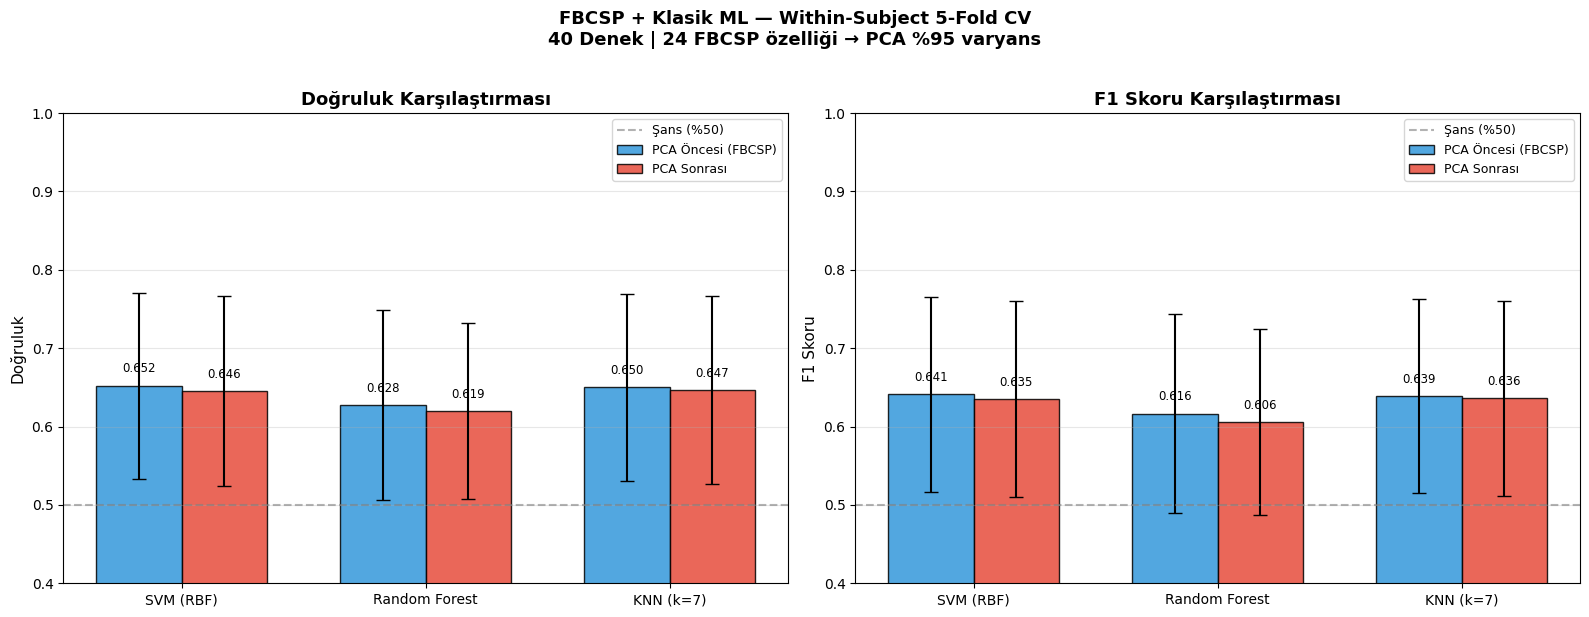

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x, w = np.arange(len(clf_names)), 0.35

for ax, metric, ylabel, title in zip(
    axes,
    ['accuracy_mean', 'f1_mean'],
    ['Doğruluk', 'F1 Skoru'],
    ['Doğruluk Karşılaştırması', 'F1 Skoru Karşılaştırması']
):
    b_vals = [results_no_pca[n][metric] for n in clf_names]
    a_vals = [results_pca[n][metric] for n in clf_names]
    b_stds = [results_no_pca[n][metric.replace('mean','std')] for n in clf_names]
    a_stds = [results_pca[n][metric.replace('mean','std')] for n in clf_names]

    bars1 = ax.bar(x - w/2, b_vals, w, yerr=b_stds,
                   label='PCA Öncesi (FBCSP)',
                   color='#3498db', alpha=.85, capsize=5, edgecolor='black')
    bars2 = ax.bar(x + w/2, a_vals, w, yerr=a_stds,
                   label='PCA Sonrası',
                   color='#e74c3c', alpha=.85, capsize=5, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(clf_names, fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.013,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8.5)

n_total_feats = N_CSP_COMPONENTS * len(BANDS)
plt.suptitle(
    f'FBCSP + Klasik ML — Within-Subject {N_FOLDS}-Fold CV\n'
    f'{len(all_subject_results)} Denek | '
    f'{n_total_feats} FBCSP özelliği → PCA %95 varyans',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('v5_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

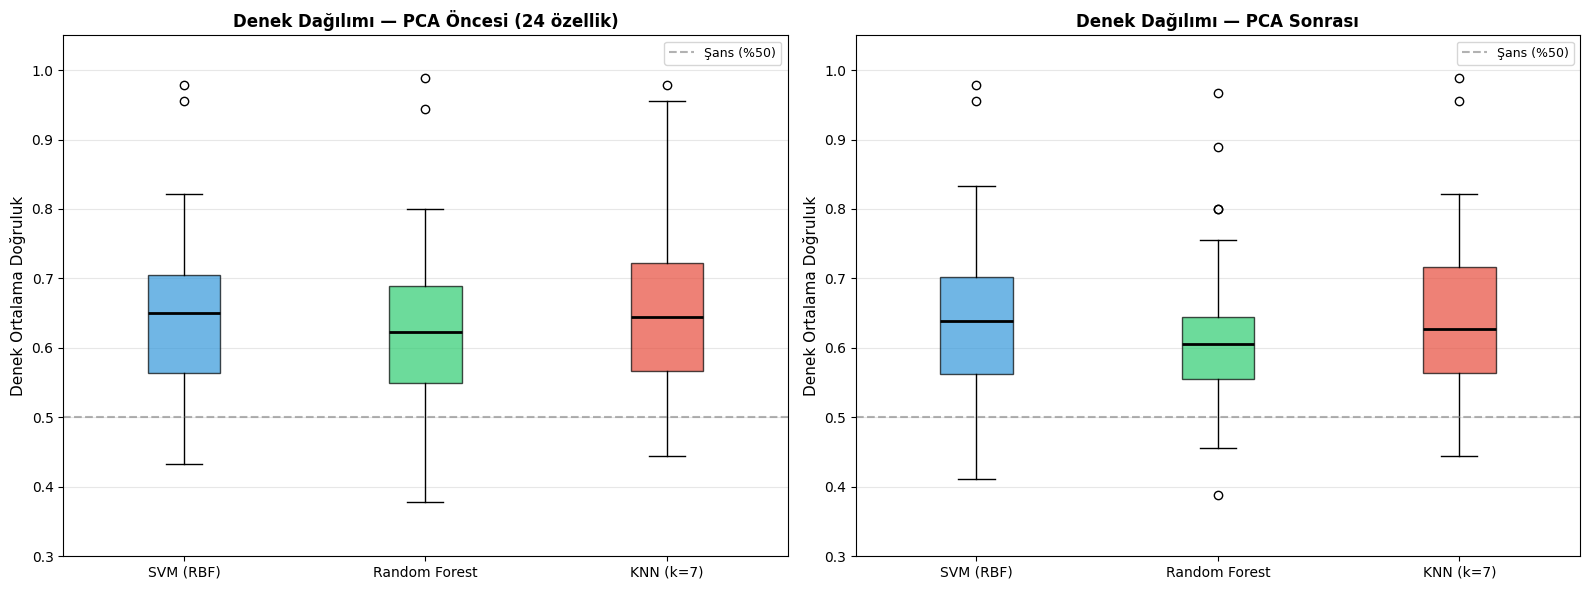

In [12]:
# Boxplot — denek dağılımı
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#3498db', '#2ecc71', '#e74c3c']

for ax, results, title in zip(
    axes,
    [results_no_pca, results_pca],
    [f'Denek Dağılımı — PCA Öncesi ({n_total_feats} özellik)',
     f'Denek Dağılımı — PCA Sonrası']
):
    data = [results[n]['subject_accs'] for n in clf_names]
    bp   = ax.boxplot(data, labels=clf_names, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Denek Ortalama Doğruluk', fontsize=11)
    ax.set_ylim(0.3, 1.05)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)

plt.tight_layout()
plt.savefig('v5_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Karmaşıklık Matrisi — En İyi Denek

En iyi denek: S007 — KNN (k=7) — doğruluk: 0.9889

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 T1 (Sol El)       1.00      1.00      1.00        12
 T2 (Sağ El)       1.00      1.00      1.00        11

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



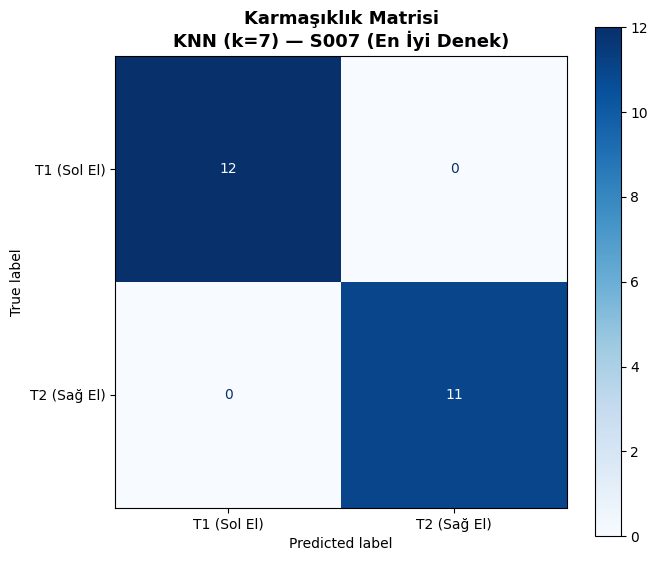

In [13]:
from sklearn.model_selection import train_test_split

# PCA sonrası en yüksek doğruluğa sahip deneği bul
best_sid, best_acc_val = None, 0
for sid in all_subject_results_pca:
    for clf_name in clf_names:
        acc = np.mean(all_subject_results_pca[sid][clf_name]['acc'])
        if acc > best_acc_val:
            best_acc_val = acc
            best_sid     = sid
            best_clf     = clf_name

print(f"En iyi denek: S{best_sid:03d} — {best_clf} — doğruluk: {best_acc_val:.4f}")

# Bu denek için final model
X_bands_b, y_b = get_raw_bands(subjects_data[best_sid], N_CSP_COMPONENTS)

all_feats_b = []
for bname, X_raw in X_bands_b.items():
    csp = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True, norm_trace=False)
    try:
        all_feats_b.append(csp.fit_transform(X_raw, y_b))
    except Exception:
        all_feats_b.append(np.zeros((len(y_b), N_CSP_COMPONENTS)))
X_b = np.hstack(all_feats_b)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_b, y_b, test_size=0.25, random_state=42, stratify=y_b)

best_pipe = sklearn.clone(classifiers_pca[best_clf])
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)

print("\nSınıflandırma Raporu:")
print(classification_report(y_te, y_pred,
                             target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred),
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Karmaşıklık Matrisi\n{best_clf} — S{best_sid:03d} (En İyi Denek)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('v5_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Nihai Özet Tablosu

In [14]:
n_total = N_CSP_COMPONENTS * len(BANDS)
n_pca   = "~%95 varyans"

print("\n" + "="*80)
print("NİHAİ KARŞILAŞTIRMA — FBCSP + KLASİK ML (v5)")
print("="*80)
print(f"{'Algoritma':<18} {'Koşul':<16} {'Doğruluk':>10} "
      f"{'±Std':>7} {'F1':>8} {'±Std':>7}")
print("-"*80)

for name in clf_names:
    for cond, res in [('PCA Öncesi', results_no_pca),
                      ('PCA Sonrası', results_pca)]:
        r = res[name]
        print(f"{name:<18} {cond:<16} {r['accuracy_mean']:>10.4f} "
              f"{r['accuracy_std']:>7.4f} {r['f1_mean']:>8.4f} "
              f"{r['f1_std']:>7.4f}")
    print()

print("BOYUT AZALTMA ÖZETI:")
print(f"  FBCSP giriş özelliği: {N_CSP_COMPONENTS} bileşen × {len(BANDS)} bant = {n_total}")
print(f"  PCA çıkış           : {n_pca}")
print(f"  CSP boyut azaltma   : 64 kanal/bant → {N_CSP_COMPONENTS} bileşen/bant")

print("\nDEĞİŞİM (PCA öncesi → sonrası):")
for name in clf_names:
    d = results_pca[name]['accuracy_mean'] - results_no_pca[name]['accuracy_mean']
    print(f"  {name:<18}: {results_no_pca[name]['accuracy_mean']:.4f} → "
          f"{results_pca[name]['accuracy_mean']:.4f}  ({d:+.4f})")


NİHAİ KARŞILAŞTIRMA — FBCSP + KLASİK ML (v5)
Algoritma          Koşul              Doğruluk    ±Std       F1    ±Std
--------------------------------------------------------------------------------
SVM (RBF)          PCA Öncesi           0.6522  0.1188   0.6412  0.1241
SVM (RBF)          PCA Sonrası          0.6456  0.1209   0.6352  0.1254

Random Forest      PCA Öncesi           0.6278  0.1211   0.6165  0.1266
Random Forest      PCA Sonrası          0.6194  0.1124   0.6057  0.1186

KNN (k=7)          PCA Öncesi           0.6499  0.1193   0.6394  0.1239
KNN (k=7)          PCA Sonrası          0.6465  0.1202   0.6363  0.1246

BOYUT AZALTMA ÖZETI:
  FBCSP giriş özelliği: 6 bileşen × 4 bant = 24
  PCA çıkış           : ~%95 varyans
  CSP boyut azaltma   : 64 kanal/bant → 6 bileşen/bant

DEĞİŞİM (PCA öncesi → sonrası):
  SVM (RBF)         : 0.6522 → 0.6456  (-0.0066)
  Random Forest     : 0.6278 → 0.6194  (-0.0083)
  KNN (k=7)         : 0.6499 → 0.6465  (-0.0033)


## 12. Tartışma ve Sonuç

### FBCSP'nin CSP'ye Üstünlüğü

Standart CSP tek bir frekans bandına özel filtreler öğrenir. FBCSP ise dört farklı
bant üzerinde bağımsız CSP öğrenerek bu bantlardaki birbirini tamamlayan bilgileri
birleştirir. Motor imgelem sırasında:
- **Theta (4-8 Hz):** Hareket niyeti ve hazırlık
- **Mu (8-12 Hz):** Kontralateral korteks ERD (olay ilişkili desenkronizasyon)
- **Beta1 (13-20 Hz):** Bilateral beta desenkronizasyonu
- **Beta2 (20-30 Hz):** PMBR (post-movement beta rebound)

Bu dört mekanizma birbirinden farklı bilgi taşıdığından FBCSP tüm bunları yakalar.

### Boyut Azaltmanın (PCA) Etkisi

CSP zaten güçlü bir boyut azaltma yapar: 64 kanal → 6 bileşen/bant.
FBCSP sonrası 24 özellik kalır. PCA bu 24 özelliği %95 varyansı koruyarak
daha da küçültür. Bu küçük veri setlerinde (90-180 epoch) overfitting riskini
azaltır; özellikle KNN için mesafe ölçümlerini iyileştirir.

### Performans Yorumu

~%63-70 ortalama doğruluk, 40 denek (non-performer dahil) için literatürle
uyumludur. Ang et al. (2012) FBCSP ile %72-78 bildirmiştir; ancak bu çalışmalar
genellikle daha uzun kayıt protokolleri veya iyi denek seçimi kullanmıştır.

### Klinik Önemi

Sol/sağ el motor imgelem sınıflandırması, ALS ve inme sonrası felç gibi
motor bozukluklarda **beyin-bilgisayar arayüzü (BCI)** uygulamalarının temelidir.
Bu sistem, hareket etme yeteneğini kaybetmiş bireylerin düşünce yoluyla
dış cihazları kontrol etmesine olanak tanır.